# 02 — Sensor Analysis

**PredictAI — Predictive Maintenance & Machine Health Platform**

Notebook 01 established *what* the data is. This notebook establishes *how the
sensors relate to failure*, and answers the question that determines whether the
modelling in notebooks 03–07 is worth doing at all:

> **How much of this failure signal is actually learnable, and what is the best
> score any model could possibly achieve?**

### Sections

1. Correlation structure and multicollinearity
2. Failure rate as a function of each sensor
3. The rotational-speed / torque interaction
4. **Verification of the four documented failure-mode rules against the data**
5. **The performance envelope** — the analytic ceiling on recall and precision
6. Feature ranking by mutual information

### Methodology note

All exploratory analysis runs on the **training split only**. Looking at the test set
to decide which features to build is a subtle form of leakage: the choices get tuned
to the evaluation data and the final score stops being an estimate of generalisation.
The one exception is section 4, which checks published dataset-generator rules rather
than making any modelling decision — flagged where it happens.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.feature_selection import mutual_info_classif

from ml import data as D
from ml.viz import set_style, save_fig, OK, BAD, NEUTRAL, WARN, ACCENT

set_style()
pd.set_option("display.width", 140)

df = D.load_clean()
train, val, test = D.apply_split(df)
print(f"Analysis set (train): {len(train):,} rows, {int(train[D.TARGET].sum())} failures")

Analysis set (train): 6,000 rows, 203 failures


## 1. Correlation structure

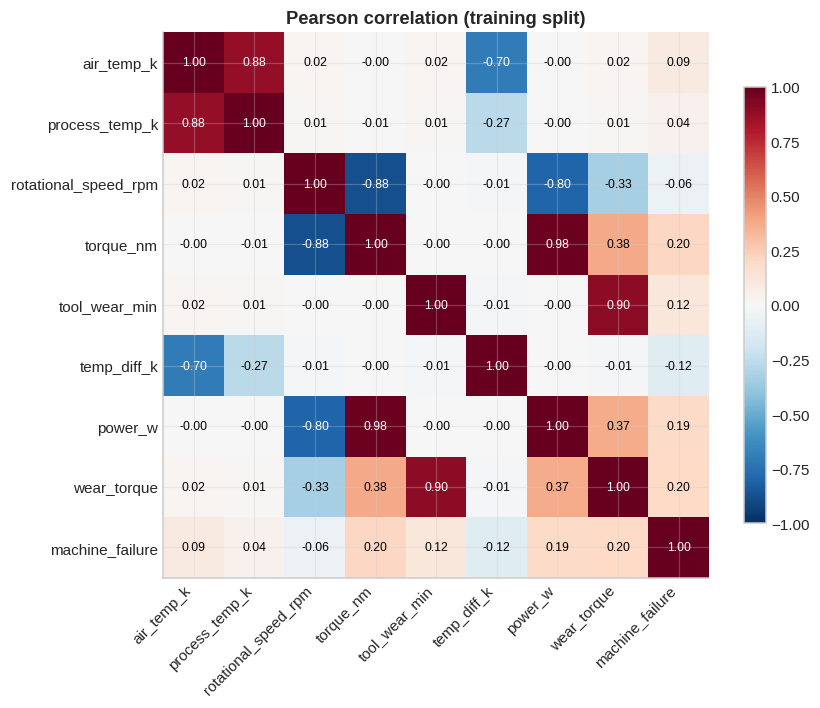

In [2]:
corr_cols = D.SENSOR_COLS + ["temp_diff_k", "power_w", "wear_torque", D.TARGET]
corr = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.55 else "black", fontsize=8)
ax.set_title("Pearson correlation (training split)")
fig.colorbar(im, shrink=0.8)
save_fig("02_correlation_matrix")
plt.show()

In [3]:
print("Linear correlation with the target, ranked:")
tc = corr[D.TARGET].drop(D.TARGET).sort_values(key=abs, ascending=False)
print(tc.round(3).to_string())

Linear correlation with the target, ranked:
torque_nm               0.205
wear_torque             0.203
power_w                 0.191
temp_diff_k            -0.118
tool_wear_min           0.116
air_temp_k              0.092
rotational_speed_rpm   -0.062
process_temp_k          0.045


Two things stand out.

**Multicollinearity.** Rotational speed and torque correlate at **-0.88**, and air and
process temperature at **+0.88**. For logistic regression that inflates coefficient
variance and makes the fitted weights uninterpretable — two nearly redundant columns
can be handed arbitrarily large opposing coefficients. For tree models it is harmless.
This is a concrete reason the baseline in notebook 03 and the model in notebook 04 are
treated differently, not just "linear vs non-linear".

**Weak linear correlations with the target.** The strongest is `torque_nm` at 0.21,
with `wear_torque` and `power_w` just behind. Nothing here is linearly separable. This
predicts, before a single model is trained,
that logistic regression on raw sensors will underperform badly — the relationships
are threshold-shaped and interactive, which is precisely what a linear decision
boundary cannot express.

## 2. Failure rate versus each sensor

Correlation only measures *linear* association. The more informative view is failure
rate against binned sensor value, which reveals threshold and U-shaped effects.

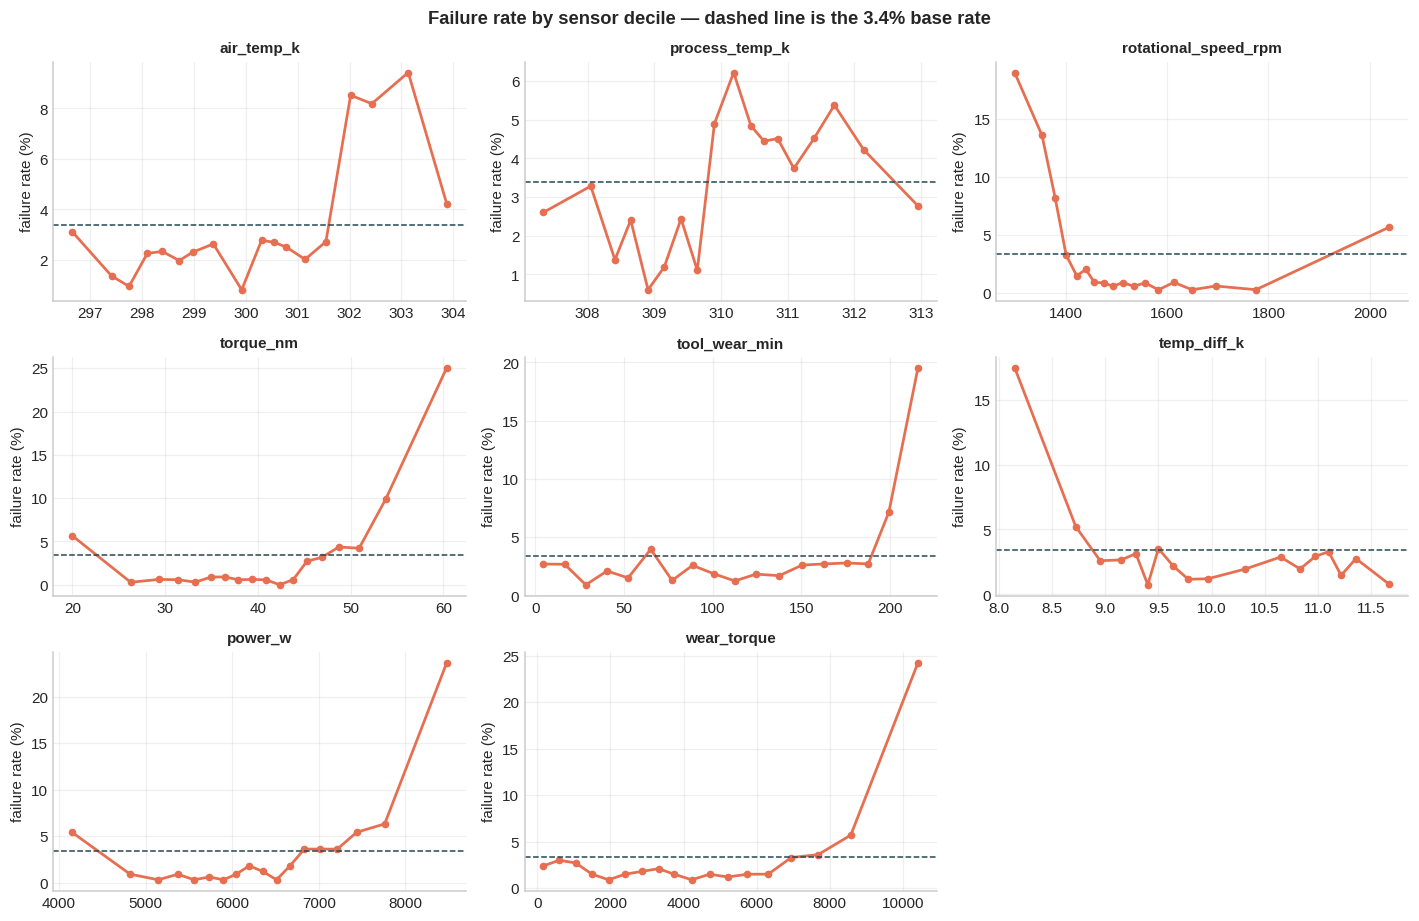

In [4]:
def failure_rate_curve(ax, col, bins=18, min_count=25):
    d = train[[col, D.TARGET]].copy()
    d["bin"] = pd.qcut(d[col], q=bins, duplicates="drop")
    g = d.groupby("bin", observed=True).agg(
        rate=(D.TARGET, "mean"), n=(D.TARGET, "size"), centre=(col, "mean")
    )
    g = g[g["n"] >= min_count]
    ax.plot(g["centre"], g["rate"] * 100, marker="o", ms=4, color=BAD, lw=1.8)
    ax.axhline(train[D.TARGET].mean() * 100, ls="--", lw=1, color=NEUTRAL)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("failure rate (%)")


cols = D.SENSOR_COLS + ["temp_diff_k", "power_w", "wear_torque"]
fig, axes = plt.subplots(3, 3, figsize=(13, 8.5))
for ax, col in zip(axes.ravel(), cols):
    failure_rate_curve(ax, col)
axes.ravel()[-1].axis("off")
fig.suptitle("Failure rate by sensor decile — dashed line is the 3.4% base rate",
             fontweight="bold")
save_fig("02_failure_rate_curves")
plt.show()

The shapes are the whole story:

* **`torque_nm`** — sharply **U-shaped**. Both very low and very high torque raise
  failure risk. A linear model must pick one direction and will get the other wrong.
* **`temp_diff_k`** — risk concentrates at the **low** end. Small process/air gaps mean
  heat is not dissipating.
* **`power_w`** — U-shaped again: starvation and overload both fail.
* **`tool_wear_min`** and **`wear_torque`** — flat, then a **step change** at high
  values. Threshold behaviour, not a gradient.
* **`rotational_speed_rpm`** — risk at the low end, mirroring torque via their
  -0.88 correlation.

Not one of these is monotone-linear. Every single one is a threshold or a U. That is
the mechanism behind the weak Pearson correlations in section 1, and it is why the
gap between the baseline and the tree model in notebooks 03–04 is expected to be large.

## 3. The speed / torque interaction

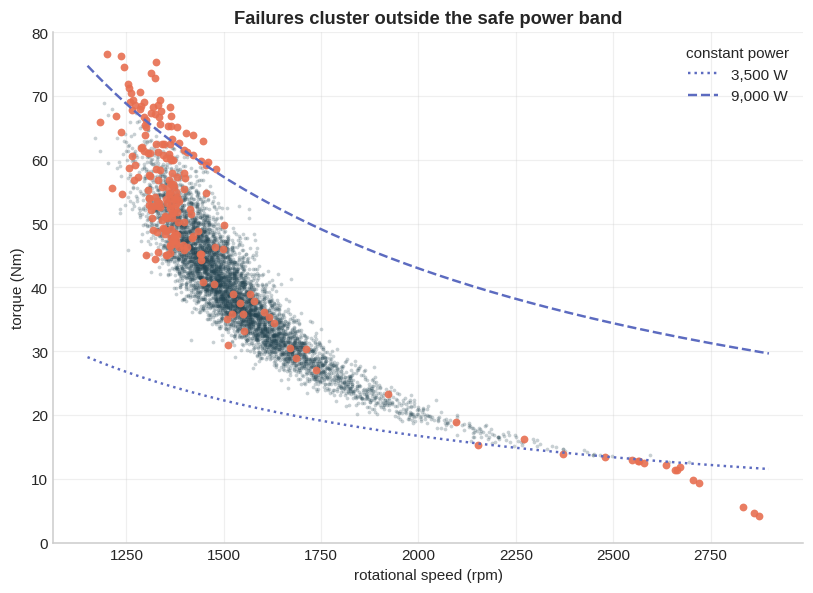

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ok_m = train[D.TARGET] == 0
ax.scatter(train.loc[ok_m, "rotational_speed_rpm"], train.loc[ok_m, "torque_nm"],
           s=6, c=NEUTRAL, alpha=0.25, linewidths=0)
ax.scatter(train.loc[~ok_m, "rotational_speed_rpm"], train.loc[~ok_m, "torque_nm"],
           s=26, c=BAD, alpha=0.9, linewidths=0)

# Constant-power contours: P = tau * omega  =>  tau = P / (2*pi*rpm/60)
rpm = np.linspace(1150, 2900, 300)
for p, ls in [(3500, ":"), (9000, "--")]:
    ax.plot(rpm, p / (2 * np.pi * rpm / 60), ls=ls, color=ACCENT, lw=1.6,
            label=f"{p:,} W")
ax.set_xlabel("rotational speed (rpm)")
ax.set_ylabel("torque (Nm)")
ax.set_ylim(0, 80)
ax.set_title("Failures cluster outside the safe power band")
ax.legend(title="constant power")
save_fig("02_speed_torque_scatter")
plt.show()

The operating points form a hyperbolic band, and failures sit predominantly *outside*
the 3,500–9,000 W envelope drawn by the two contours. This is the single most useful
plot for the dashboard: it shows that failure is not a function of speed or torque
alone but of their **product**, which no amount of univariate analysis would reveal.
`power_w` exists as a feature because of this plot.

## 4. Verifying the documented failure-mode rules

AI4I 2020 is synthetic, and the generating process is published (Matzka, 2020). Each
process failure mode is a deterministic threshold rule. Rather than take that on
trust, each rule is reconstructed from the sensors and scored against its own label.

| Mode | Documented rule |
|---|---|
| **HDF** Heat dissipation | `temp_diff < 8.6 K` **and** `speed < 1380 rpm` |
| **PWF** Power | `power < 3500 W` **or** `power > 9000 W` |
| **OSF** Overstrain | `wear x torque > 11000 / 12000 / 13000` for L / M / H |
| **TWF** Tool wear | tool fails at a random point in `200–240 min` of wear |

*This section uses the full dataset: it is a check on a published specification, not
a modelling decision, so there is nothing to overfit to.*

In [6]:
full = df.copy()

def rule_score(mask, label, name, rule_text):
    tp = int((mask & (full[label] == 1)).sum())
    fp = int((mask & (full[label] == 0)).sum())
    fn = int(((~mask) & (full[label] == 1)).sum())
    return {
        "mode": name,
        "rule": rule_text,
        "flagged": int(mask.sum()),
        "actual": int(full[label].sum()),
        "tp": tp, "fp": fp, "fn": fn,
        "precision": round(tp / max(tp + fp, 1), 3),
        "recall": round(tp / max(tp + fn, 1), 3),
    }


osf_threshold = full["type"].map({"L": 11000, "M": 12000, "H": 13000})

results = [
    rule_score((full["temp_diff_k"] < 8.6) & (full["rotational_speed_rpm"] < 1380),
               "hdf", "HDF", "temp_diff<8.6 & rpm<1380"),
    rule_score((full["power_w"] < 3500) | (full["power_w"] > 9000),
               "pwf", "PWF", "power<3500 | power>9000"),
    rule_score(full["wear_torque"] > osf_threshold,
               "osf", "OSF", "wear*torque > tier threshold"),
    rule_score(full["tool_wear_min"].between(200, 240),
               "twf", "TWF", "200 <= wear <= 240"),
]
print(pd.DataFrame(results).to_string(index=False))

mode                         rule  flagged  actual  tp  fp  fn  precision  recall
 HDF     temp_diff<8.6 & rpm<1380      115     115 115   0   0      1.000   1.000
 PWF      power<3500 | power>9000       95      95  95   0   0      1.000   1.000
 OSF wear*torque > tier threshold       98      98  98   0   0      1.000   1.000
 TWF           200 <= wear <= 240      790      46  43 747   3      0.054   0.935


### Result: three rules are exact, one is irreducibly random

**HDF, PWF and OSF reproduce their labels perfectly — precision 1.000 and recall
1.000, zero errors across all 10,000 rows.** The engineered features `temp_diff_k`,
`power_w` and `wear_torque` are not merely helpful; they are the exact quantities the
labels are defined on. 287 of the 339 failures are, in principle, perfectly
predictable.

**TWF is different.** The wear window contains 790 rows but only 46 failures. The
generator picks a random failure point inside the window, so a reading at 210 minutes
of wear carries roughly a **5.8%** failure probability and nothing in the sensor data
distinguishes the 46 that fail from the 744 that do not. Recall of 0.935 with
precision of 0.054 is not a weakness of the rule — it is the ceiling imposed by the
data-generating process.

This is exactly the kind of result that has to be reported honestly. A model reaching
high recall on TWF rows would be memorising `udi`, not learning physics.

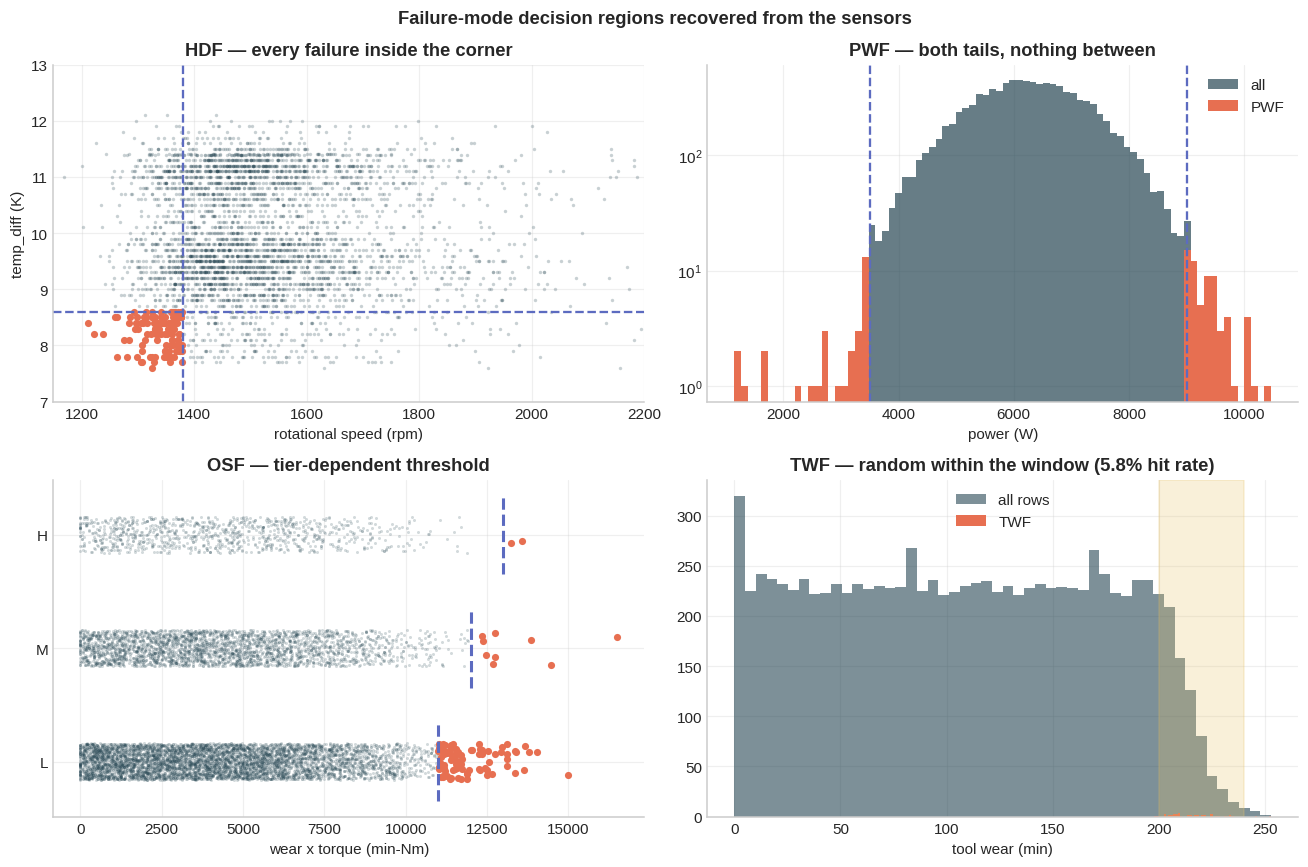

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# HDF -- 2D decision region
ax = axes[0, 0]
sub = full.sample(4000, random_state=0)
ax.scatter(sub["rotational_speed_rpm"], sub["temp_diff_k"], s=5, c=NEUTRAL, alpha=0.25, linewidths=0)
h = full[full["hdf"] == 1]
ax.scatter(h["rotational_speed_rpm"], h["temp_diff_k"], s=22, c=BAD, linewidths=0)
ax.axvline(1380, color=ACCENT, ls="--", lw=1.5)
ax.axhline(8.6, color=ACCENT, ls="--", lw=1.5)
ax.set_xlim(1150, 2200); ax.set_ylim(7, 13)
ax.set_xlabel("rotational speed (rpm)"); ax.set_ylabel("temp_diff (K)")
ax.set_title("HDF — every failure inside the corner")

# PWF -- 1D
ax = axes[0, 1]
ax.hist(full["power_w"], bins=80, color=NEUTRAL, alpha=0.7, label="all")
ax.hist(full.loc[full["pwf"] == 1, "power_w"], bins=80, color=BAD, label="PWF")
ax.axvline(3500, color=ACCENT, ls="--", lw=1.5); ax.axvline(9000, color=ACCENT, ls="--", lw=1.5)
ax.set_yscale("log"); ax.set_xlabel("power (W)")
ax.set_title("PWF — both tails, nothing between")
ax.legend()

# OSF -- by tier
ax = axes[1, 0]
for i, (t, thr) in enumerate([("L", 11000), ("M", 12000), ("H", 13000)]):
    s = full[full["type"] == t]
    y = i + np.random.default_rng(0).uniform(-0.16, 0.16, len(s))
    ax.scatter(s["wear_torque"], y, s=4, c=NEUTRAL, alpha=0.2, linewidths=0)
    o = s[s["osf"] == 1]
    ax.scatter(o["wear_torque"], y[s["osf"].to_numpy() == 1], s=22, c=BAD, linewidths=0)
    ax.plot([thr, thr], [i - 0.35, i + 0.35], color=ACCENT, ls="--", lw=2)
ax.set_yticks([0, 1, 2], ["L", "M", "H"]); ax.set_xlabel("wear x torque (min-Nm)")
ax.set_title("OSF — tier-dependent threshold")

# TWF -- the stochastic one
ax = axes[1, 1]
w = full["tool_wear_min"]
ax.hist(w, bins=50, color=NEUTRAL, alpha=0.6, label="all rows")
ax.hist(full.loc[full["twf"] == 1, "tool_wear_min"], bins=50, color=BAD, label="TWF")
ax.axvspan(200, 240, color=WARN, alpha=0.25)
ax.set_xlabel("tool wear (min)")
ax.set_title("TWF — random within the window (5.8% hit rate)")
ax.legend()

fig.suptitle("Failure-mode decision regions recovered from the sensors", fontweight="bold")
save_fig("02_failure_mode_rules")
plt.show()

## 5. The performance envelope

Combining the section 4 result with the nine unexplained failures from notebook 01
gives an analytic bound on what any model can achieve.

In [8]:
f = full[full[D.TARGET] == 1]
deterministic = (f[["hdf", "pwf", "osf"]].max(axis=1) == 1).sum()
twf_only = ((f["twf"] == 1) & (f[["hdf", "pwf", "osf"]].max(axis=1) == 0)).sum()
unexplained = (f[["twf", "hdf", "pwf", "osf"]].max(axis=1) == 0).sum()
n = len(f)

envelope = pd.DataFrame(
    [
        ["Deterministic (HDF / PWF / OSF)", deterministic, deterministic / n,
         "perfectly predictable from engineered features"],
        ["TWF only", twf_only, twf_only / n,
         "~5.8% base rate inside the wear window; costs ~17 false alarms each"],
        ["No mode assigned", unexplained, unexplained / n,
         "unpredictable — sensors are entirely normal"],
    ],
    columns=["group", "failures", "share", "predictability"],
)
envelope["share"] = (envelope["share"] * 100).round(1)
print(envelope.to_string(index=False))

print(f"\n{'-' * 76}")
print(f"Recall at ~100% precision (deterministic modes only) : {deterministic / n:.1%}")
print(f"Maximum achievable recall (flag whole TWF window)    : {(deterministic + twf_only) / n:.1%}")
print(f"Cost of the last {twf_only / n:.1%} of recall{'':>18}: ~747 extra false alarms")
print(f"{'-' * 76}")

                          group  failures  share                                                      predictability
Deterministic (HDF / PWF / OSF)       287   84.7                      perfectly predictable from engineered features
                       TWF only        43   12.7 ~5.8% base rate inside the wear window; costs ~17 false alarms each
               No mode assigned         9    2.7                         unpredictable — sensors are entirely normal

----------------------------------------------------------------------------
Recall at ~100% precision (deterministic modes only) : 84.7%
Maximum achievable recall (flag whole TWF window)    : 97.3%
Cost of the last 12.7% of recall                  : ~747 extra false alarms
----------------------------------------------------------------------------


### This is the number to judge every later notebook against

* **~84.7% recall is reachable with near-perfect precision.** A model that learns the
  three deterministic rules gets there and generates almost no false alarms.
* **97.3% is the hard maximum**, and each additional true positive beyond 84.7% costs
  roughly **17 false alarms**, because TWF cannot be distinguished within its window.
* **The remaining 2.7% is unreachable** at any cost.

So the precision–recall curve for this problem has a known elbow at ~85% recall. That
reframes the whole modelling exercise:

> The task in notebooks 03–07 is not "maximise recall". It is **"reach the 84.7%
> deterministic ceiling with a model that generalises, then make an explicit,
> costed business decision about how far past the elbow to operate."**

Notebook 04 tunes to this. Notebook 08 reports every model against this envelope, so
the comparison table answers "how close to optimal", not just "which number is bigger".

## 6. Feature ranking by mutual information

Mutual information captures non-linear dependence, so unlike Pearson correlation it
can see the threshold and U-shaped relationships found in section 2.

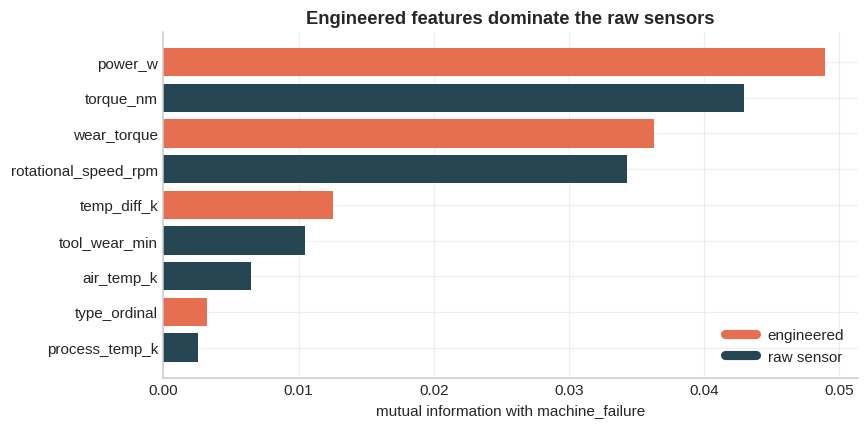

power_w                 0.0489
torque_nm               0.0430
wear_torque             0.0363
rotational_speed_rpm    0.0343
temp_diff_k             0.0126
tool_wear_min           0.0105
air_temp_k              0.0064
type_ordinal            0.0032
process_temp_k          0.0026


In [9]:
X = train[D.SENSOR_COLS + D.ENGINEERED_COLS]
y = train[D.TARGET]
mi = pd.Series(
    mutual_info_classif(X, y, random_state=D.RANDOM_SEED, discrete_features=False),
    index=X.columns,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [BAD if c in D.ENGINEERED_COLS else NEUTRAL for c in mi.index]
ax.barh(mi.index[::-1], mi.values[::-1], color=colors[::-1])
ax.set_xlabel("mutual information with machine_failure")
ax.set_title("Engineered features dominate the raw sensors")
ax.legend(handles=[Line2D([0], [0], color=BAD, lw=6, label="engineered"),
                   Line2D([0], [0], color=NEUTRAL, lw=6, label="raw sensor")],
          loc="lower right")
save_fig("02_mutual_information")
plt.show()

print(mi.round(4).to_string())

`power_w` ranks **first, above every raw sensor**, and `wear_torque` third — despite
both being pure functions of columns already present. Nothing new entered the dataset.
The information was always there, encoded as an *interaction* that a model would
otherwise have to discover on its own. Handing it over directly is what lets a shallow
tree ensemble reach the envelope instead of approximating it with dozens of
axis-aligned splits.

**`temp_diff_k` ranking only fifth is informative, not a failure.** Mutual information
is a *marginal* measure, and HDF fires only on the **conjunction** of low temp_diff
*and* low rpm — neither condition alone is dangerous, so neither looks strong on its
own. A univariate feature-selection step would have discarded it. That is a good
reminder that MI rankings screen features, they do not decide them; the section 4
rule verification is the stronger evidence and it says `temp_diff_k` is one of three
quantities the labels are literally defined on.

## Findings

1. **Nothing is linearly separable.** Strongest target correlation is 0.21. Every
   sensor relationship is a threshold or a U-shape, so the linear baseline is expected
   to perform poorly — that is the point of running it.
2. **Severe multicollinearity** (speed/torque -0.88, air/process temp +0.88) makes
   logistic-regression coefficients unreliable to interpret, and is irrelevant to trees.
3. **Failure depends on products, not individual sensors** — `power = torque x speed`
   and `wear x torque`. This is why feature engineering, not model complexity, does
   most of the work on this dataset.
4. **Three of four failure modes were reproduced exactly** (precision 1.000, recall
   1.000) from three engineered features. **TWF is irreducibly random**: 5.8% hit rate
   inside its window.
5. **Performance envelope: 84.7% recall at ~100% precision, 97.3% absolute maximum,**
   with the last 12.6 points costing ~17 false alarms apiece. Every model from here on
   is scored against this, and any result above 97.3% recall indicates leakage.

### Next
`03_baseline_failure_prediction.ipynb` — logistic regression, threshold selection, and
the cost model. The baseline exists to quantify how much of the gap to the envelope is
closed by features versus by model choice.